<a href="https://colab.research.google.com/github/rameenhamad/ML_Tasks/blob/main/3_Visualize_Feature_Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv(r"/content/Titanic-Dataset.csv")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#as cabin have almost 77 persent null values so it is appropriate to drop this column
df.drop("Cabin", axis=1, inplace=True)

In [ ]:
df.shape

(891, 11)

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


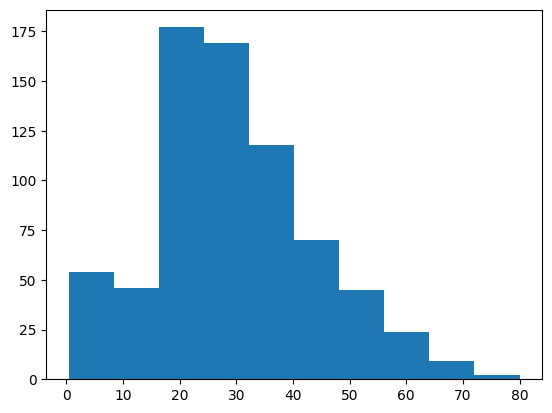

In [ ]:
age = df['Age']
plt.hist(age)
plt.show()

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.45,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df['Embarked'] = oe.fit_transform(df[['Embarked']])
df['Embarked'].value_counts()

,count
Embarked,
2.0,646
0.0,168
1.0,77


In [ ]:
df['Sex'] = df['Sex'].apply(lambda x: 1 if x=='female' else 0)
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,2.0


In [ ]:
#dropping ticket while we have peseenger class and fare no need for ticket number
df.drop("Ticket", axis=1, inplace=True)

In [ ]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,2.0


In [ ]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')

In [ ]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,2.0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,0.0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,2.0,Miss


In [ ]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [ ]:
df['Title_Category'] = df['Title'].apply(
    lambda x: 'Women' if x in ['Mrs', 'Ms', 'Miss', 'Mme', 'Mlle']
    else 'Children' if x == 'Master'
    else 'Military' if x in ['Capt', 'Col', 'Major']
    else 'Notables' if x in ['Lady', 'Countess', 'Jonkheer', 'Sir', 'Don', 'Rev', 'Dr']
    else 'Men'
)
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Title_Category
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,2.0,Mr,Men
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,0.0,Mrs,Women
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,2.0,Miss,Women


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
df_en = ohe.fit_transform(df[['Title_Category']])
df_en

array([[1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.]])

In [ ]:
cols = ohe.get_feature_names_out()
cols

array(['Title_Category_Men', 'Title_Category_Military',
       'Title_Category_Notables', 'Title_Category_Women'], dtype=object)

In [ ]:
dt = pd.DataFrame(data=df_en, columns=['Category_Men', 'Category_Military','Category_Notables', 'Category_Women'])

In [ ]:
df = pd.concat([df, dt], axis=1)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Title_Category,Category_Men,Category_Military,Category_Notables,Category_Women
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,2.0,Mr,Men,1.0,0.0,0.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,0.0,Mrs,Women,0.0,0.0,0.0,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,2.0,Miss,Women,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,2.0,Mrs,Women,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,2.0,Mr,Men,1.0,0.0,0.0,0.0


In [ ]:
df.drop(['Name', 'Title_Category', 'Title', 'PassengerId'], axis=1, inplace=True)
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Category_Men,Category_Military,Category_Notables,Category_Women
0,0,3,0,22.0,1,0,7.2500,2.0,1.0,0.0,0.0,0.0
1,1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,1.0
2,1,3,1,26.0,0,0,7.9250,2.0,0.0,0.0,0.0,1.0


In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
model = rf.fit(X_train_transformed, y_train)
y_pred = model.predict(X_test_transformed)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("acuuracy score: ", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

acuuracy score:  0.8435754189944135
[[92 13]
 [15 59]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



In [ ]:
importances = model.feature_importances_
col = X.columns
for name, score in zip(col, importances):
    print(name,score)

Pclass 0.08392809247016901
Sex 0.12812758743627056
Age 0.23014973761677704
SibSp 0.05434198703028604
Parch 0.03293161260656476
Fare 0.24930392175791014
Embarked 0.03297370445642517
Category_Men 0.1063531314931846
Category_Military 0.0031209360684354686
Category_Notables 0.006158014416231274
Category_Women 0.07261127464774594


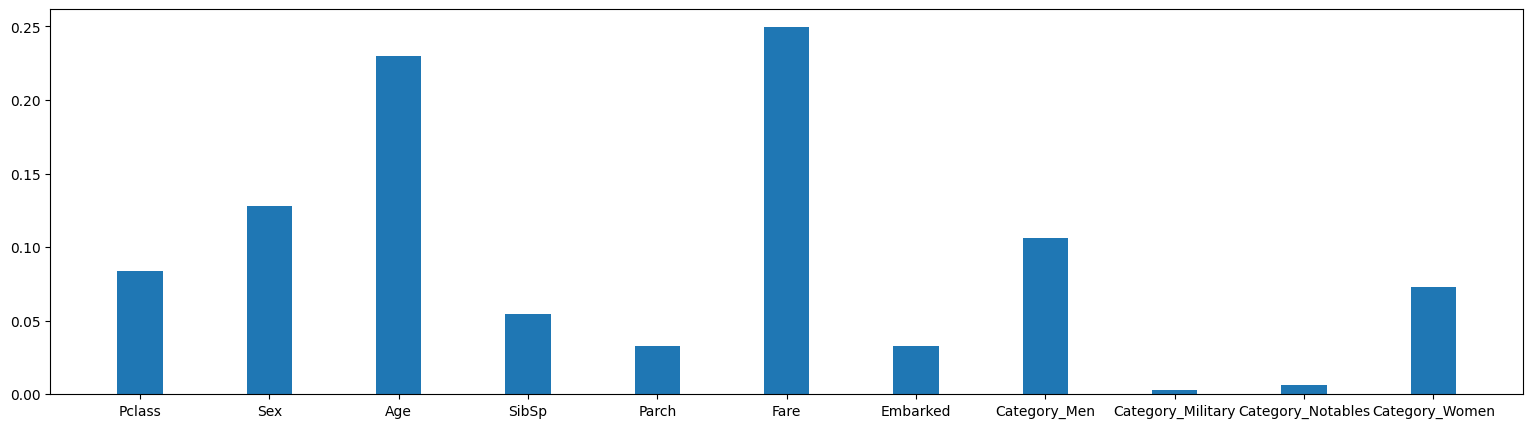

In [ ]:
bar_width = 0.35

plt.figure(figsize=(19,5))
plt.bar(col, importances, bar_width)
plt.show()